<a href="https://colab.research.google.com/github/sabahoth01/Machine-learning-tasks/blob/brunnotte%2Ftask1/task4s.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Васаулюа Брюнотт Тази

## Задача 4

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
custom_colors = ["#FF6F61", "#FFA500", "#DAA520", "#17CEEB", "#32CD32", "#FF00FF", "#DC143C"]
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.multiclass import OutputCodeClassifier
from sklearn.multiclass import OneVsOneClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import cross_validate
from sklearn.multioutput import MultiOutputRegressor, RegressorChain
from sklearn.metrics import r2_score
from sklearn.linear_model import Ridge
from sklearn.multioutput import MultiOutputClassifier, ClassifierChain
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, hamming_loss
from sklearn.model_selection import RandomizedSearchCV,  KFold

## 1. Multiclass

Датасет из [Kaggle : Iris species](https://www.kaggle.com/datasets/uciml/iris?resource=download)

### Описание

Это многомерный датасет, который описывает характеристики 150 цветков каждого вида ириса из трех различных видов.

Признаки:
- Id
- SepalLengthCm : Длина чашелистика (в см)
- SepalWidthCm : Ширина чашелистика (в см)
- PetalLengthCm : Длина лепестка (в см)
- PetalWidthCm : Ширина лепестка (в см)
- Species : Ирис сетчатый (Iris setosa), Ирис разноцветный (Iris versicolor),Ирис виргинский (Iris virginica) :

In [50]:
data = pd.read_csv(r"/content/Iris.csv")
data

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


# EDA

In [51]:
data.isnull().sum()

,0
Id,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


In [52]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [53]:
data.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [54]:
data.groupby('Species').mean()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
Species,,,,,
Iris-setosa,25.5,5.006,3.418,1.464,0.244
Iris-versicolor,75.5,5.936,2.770,4.260,1.326
Iris-virginica,125.5,6.588,2.974,5.552,2.026


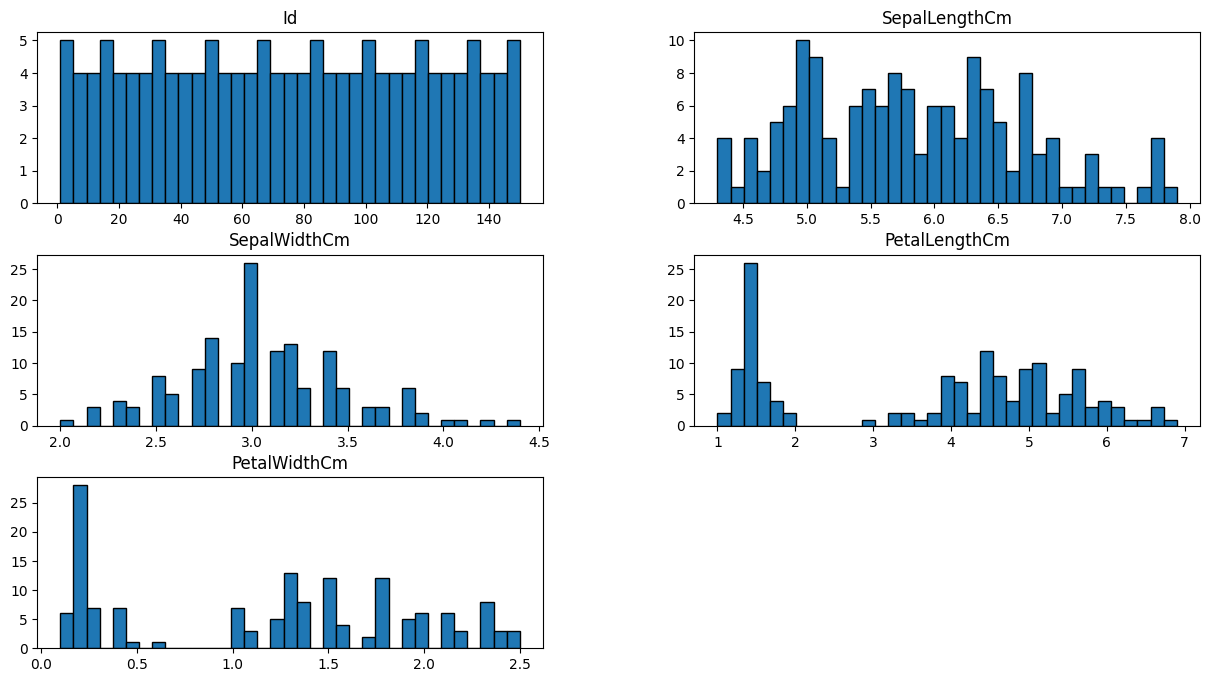

In [55]:
data.hist(figsize=(15, 8), edgecolor='black', bins=35, grid=False)
plt.show()

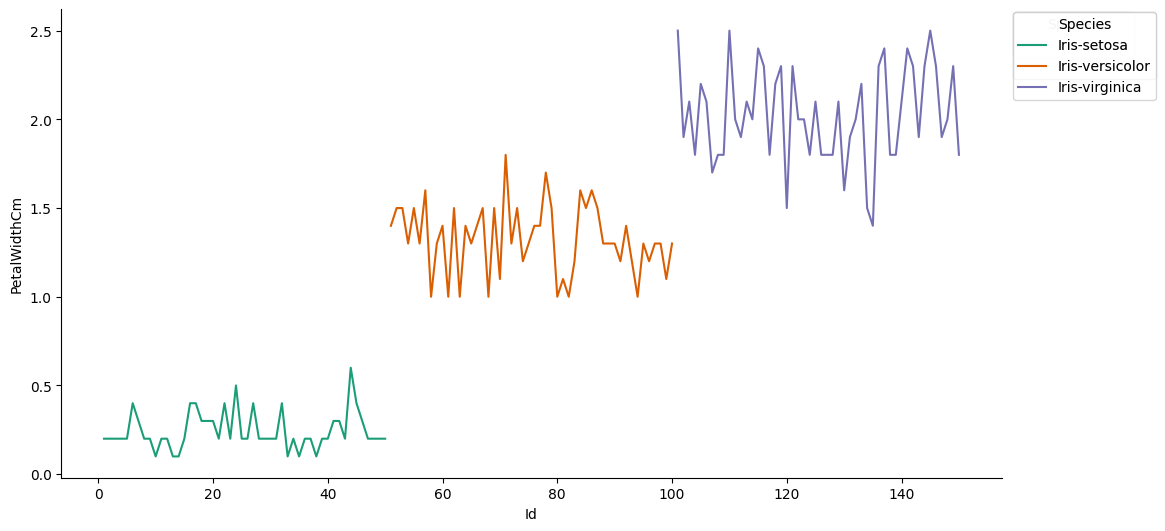

In [56]:
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['Id']
  ys = series['PetalWidthCm']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = data.sort_values('Id', ascending=True)
for i, (series_name, series) in enumerate(df_sorted.groupby('Species')):
  _plot_series(series, series_name, i)
  fig.legend(title='Species', bbox_to_anchor=(1, 1), loc='upper left')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Id')
_ = plt.ylabel('PetalWidthCm')

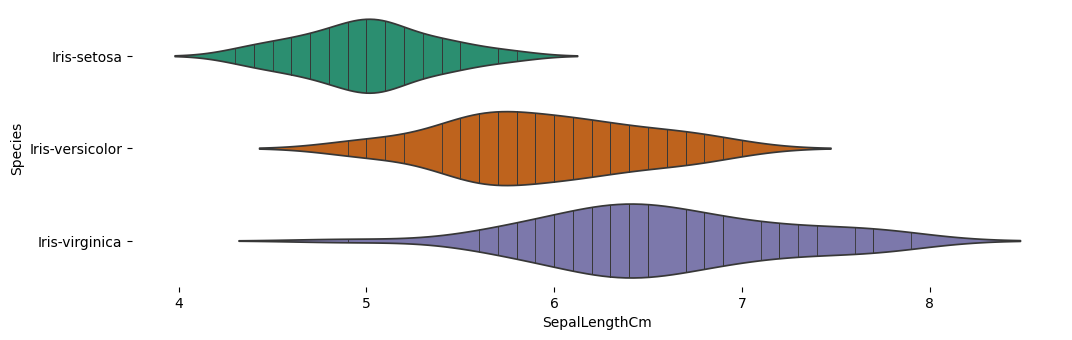

In [57]:
figsize = (12, 1.2 * len(data['Species'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(data, x='SepalLengthCm', y='Species', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

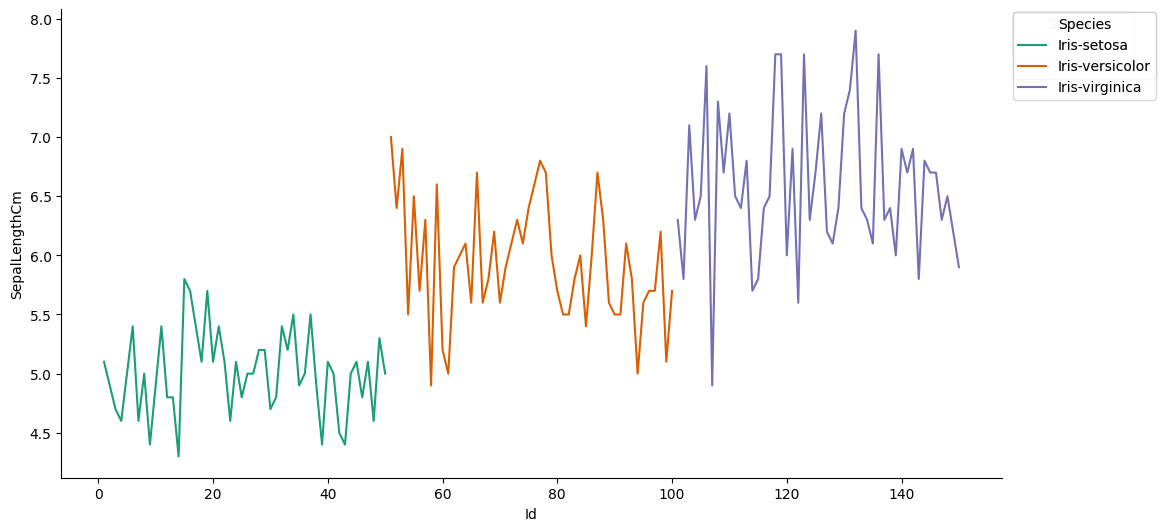

In [58]:
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['Id']
  ys = series['SepalLengthCm']

  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = data.sort_values('Id', ascending=True)
for i, (series_name, series) in enumerate(df_sorted.groupby('Species')):
  _plot_series(series, series_name, i)
  fig.legend(title='Species', bbox_to_anchor=(1, 1), loc='upper left')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Id')
_ = plt.ylabel('SepalLengthCm')

array([[<Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
        <Axes: ylabel='Density'>],
       [<Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
        <Axes: ylabel='Density'>],
       [<Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
        <Axes: ylabel='Density'>],
       [<Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
        <Axes: ylabel='Density'>],
       [<Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
        <Axes: ylabel='Density'>],
       [<Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
        <Axes: ylabel='Density'>],
       [<Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
        <Axes: ylabel='Density'>],
       [<Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
        <Axes: ylabel='Density'>],
       [<Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
        <Axes: ylabel='Density'>]], dtype=object)

<Figure size 1900x1900 with 0 Axes>

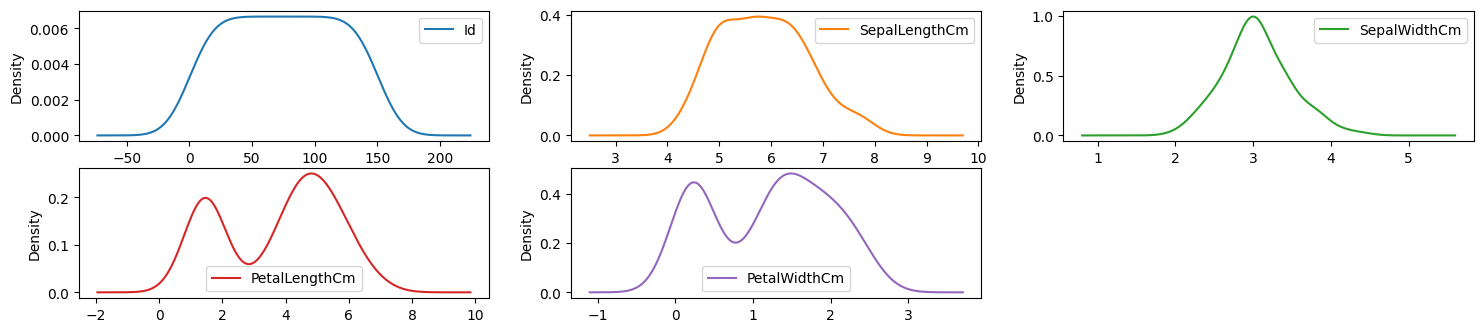

In [59]:
plt.figure(figsize=(19, 19))
data.plot(kind='density', subplots=True, layout=(9,3), sharex=False, sharey=False, figsize=(18, 18))

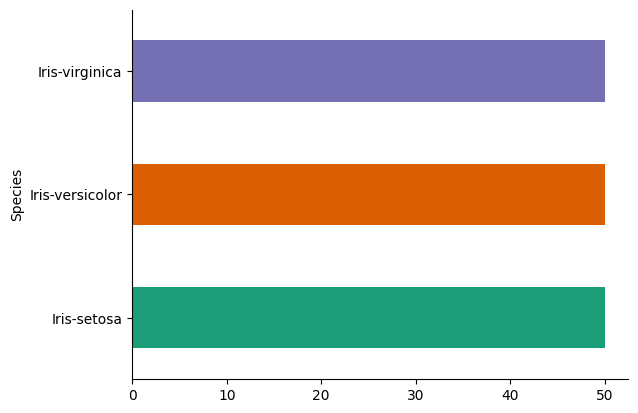

In [60]:
data.groupby('Species').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

### Вывод по EDA

- Нет пропущенных данных,
- Ирис виргинский (Iris virginica) характеризуется очень широкими лепестками и длинными чашелистиками.
- одинаковое количество каждого вида в наборе данных.


### Преобразуем данные

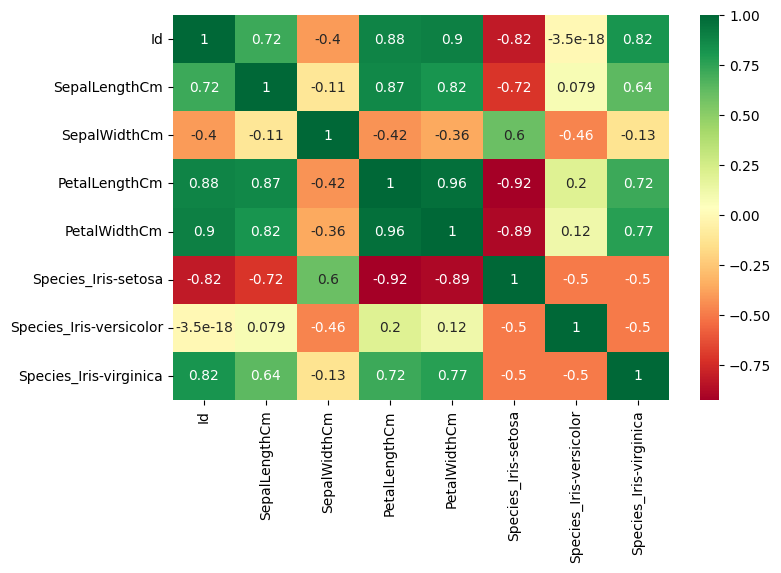

In [61]:
dum_data = pd.get_dummies(data, columns=['Species'])
sns.heatmap(dum_data.corr(), annot=True, cmap='RdYlGn')
fig = plt.gcf()
fig.set_size_inches(8, 5)
plt.show()

## Используя стратегии OneVsRest, OneVsOne и OutputCode решите задачу Multiclass classification для каждого из пройденных базового алгоритма классификации (logistic regression, svm, knn, naive bayes, decision tree). При обучении использовать подбор гиперпараметров, кросс-валидацию и при необходимости масштабирование данных, добиться наилучшего качества предсказания. Замерить время обучения каждой модели для каждой стратегии. Для оценки качества моделей используйте метрику AUC-ROC.

###   Обучим модели/ выборка гиперпараметров

In [62]:
X = data.drop('Species' , axis='columns')
y = data['Species']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=37)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [63]:
param_grid = {'C': [1E-3, 1E-1, 1, 1E+1, 1E+3]}
# searcher = GridSearchCV(LogisticRegression(random_state=37), param_grid=param_grid, cv=5, scoring="roc_auc_ovr", error_score="raise")
searcher = GridSearchCV(LogisticRegression(random_state=37, multi_class='multinomial', solver='lbfgs'), param_grid=param_grid, cv=5, scoring="roc_auc_ovr", error_score="raise")
searcher = searcher.fit(X_train_scaled, y_train)
best_logreg_params = searcher.best_params_
print("Best params =", best_logreg_params)

Best params = {'C': 0.1}


In [64]:
param_grid = {"kernel": ["linear", "rbf"],
              "C": [0.1, 0.25, 0.5, 0.75, 1],
              "gamma": ["scale", "auto", 1E-3, 1E-1, 1]}

searcher = GridSearchCV(SVC(random_state=37, probability=True), param_grid=param_grid, cv=5)
searcher = searcher.fit(X_train_scaled, y_train)
best_svc_params = searcher.best_params_
print("Best params: ", best_svc_params)

Best params:  {'C': 0.25, 'gamma': 'scale', 'kernel': 'linear'}


In [65]:

param_grid = [{"n_neighbors": [1, 3, 5, 7, 9, 11, 13, 15, 17, 19],
               "weights": ['distance', 'uniform']}]

searcher = GridSearchCV(KNeighborsClassifier(), param_grid=param_grid, cv=5, scoring="roc_auc_ovr", error_score="raise")
searcher = searcher.fit(X_train_scaled, y_train)
best_knn_params = searcher.best_params_
print("Best params =", str(best_knn_params))

Best params = {'n_neighbors': 5, 'weights': 'distance'}


In [66]:
param_grid = [{"var_smoothing": np.logspace(0, -10, num=100)}]

searcher = GridSearchCV(GaussianNB(), param_grid=param_grid, cv=5, scoring="roc_auc_ovr", error_score="raise")
searcher = searcher.fit(X_train_scaled, y_train)
best_gnb_params = searcher.best_params_
print("Best params =", str(best_gnb_params))

Best params = {'var_smoothing': 0.12328467394420663}


In [67]:

param_grid = [{"criterion": ["gini", "entropy", "log_loss"],
               "splitter": ["best", "random"],
               "max_depth": [10, 20, 30],
               "min_samples_split": [2, 5, 10],
               "min_samples_leaf": [2, 5, 10],
               "max_features": [2, 5, 10]}]

searcher = GridSearchCV(DecisionTreeClassifier(random_state=19), param_grid=param_grid, cv=5, scoring="roc_auc_ovr", error_score="raise")
searcher = searcher.fit(X_train_scaled, y_train)
best_dt_params = searcher.best_params_
print("Best params =", str(best_dt_params))

Best params = {'criterion': 'gini', 'max_depth': 10, 'max_features': 5, 'min_samples_leaf': 2, 'min_samples_split': 2, 'splitter': 'random'}


In [68]:

def measure_fit_time(model, X, y):
    return cross_validate(model, X, y, cv=5)["fit_time"].mean()
accuracies = {}
times = {}

## OneVsRest

In [69]:
ovr_logreg = OneVsRestClassifier(LogisticRegression(**best_logreg_params, random_state=37)).fit(X_train_scaled, y_train)
accuracy = accuracy_score(y_test, ovr_logreg.predict(X_test_scaled))
fit_time = measure_fit_time(ovr_logreg, X_train_scaled, y_train)
accuracies["OVR_Logreg"] = accuracy
times["OVR_Logreg"] = fit_time
print(f"OVR_Logreg accuracy {accuracy}")
print(f"OVR_Logreg time {fit_time}")

OVR_Logreg accuracy 1.0
OVR_Logreg time 0.011501407623291016


In [70]:

ovr_svm = OneVsRestClassifier(SVC(**best_svc_params, random_state=37, probability=True)).fit(X_train_scaled, y_train)
accuracy = accuracy_score(y_test, ovr_svm.predict(X_test_scaled))
fit_time = measure_fit_time(ovr_svm, X_train_scaled, y_train)
accuracies["OVR_SVM"] = accuracy
times["OVR_SVM"] = fit_time
print(f"OVR_SVM accuracy {accuracy}")
print(f"OVR_SVM time {fit_time}")

OVR_SVM accuracy 1.0
OVR_SVM time 0.0091461181640625


In [71]:

ovr_knn = OneVsRestClassifier(KNeighborsClassifier(**best_knn_params)).fit(X_train_scaled, y_train)
accuracy = accuracy_score(y_test, ovr_knn.predict(X_test_scaled))
fit_time = measure_fit_time(ovr_knn, X_train_scaled, y_train)
accuracies["OVR_KNN"] = accuracy
times["OVR_KNN"] = fit_time
print(f"OVR_KNN accuracy {accuracy}")
print(f"OVR_KNN time {fit_time}")

OVR_KNN accuracy 1.0
OVR_KNN time 0.0050961971282958984


In [72]:

ovr_nb = OneVsRestClassifier(GaussianNB(**best_gnb_params)).fit(X_train_scaled, y_train)
accuracy = accuracy_score(y_test, ovr_nb.predict(X_test_scaled))
fit_time = measure_fit_time(ovr_nb, X_train_scaled, y_train)
accuracies["OVR_GNB"] = accuracy
times["OVR_GNB"] = fit_time
print(f"OVR_GNB accuracy {accuracy}")
print(f"OVR_GNB time {fit_time}")

OVR_GNB accuracy 1.0
OVR_GNB time 0.006834506988525391


In [73]:
ovr_dt = OneVsRestClassifier(DecisionTreeClassifier(**best_dt_params, random_state=37)).fit(X_train_scaled, y_train)
accuracy = accuracy_score(y_test, ovr_dt.predict(X_test_scaled))
fit_time = measure_fit_time(ovr_dt, X_train_scaled, y_train)
accuracies["OVR_DT"] = accuracy
times["OVR_DT"] = fit_time
print(f"OVR_DT accuracy {accuracy}")
print(f"OVR_DT time {fit_time}")

OVR_DT accuracy 1.0
OVR_DT time 0.006658411026000977


## OneVsOne

In [74]:

ovo_logreg = OneVsOneClassifier(LogisticRegression(**best_logreg_params, random_state=37)).fit(X_train_scaled, y_train)
accuracy = accuracy_score(y_test, ovo_logreg.predict(X_test_scaled))
fit_time = measure_fit_time(ovo_logreg, X_train_scaled, y_train)
accuracies["OVO_Logreg"] = accuracy
times["OVO_Logreg"] = fit_time
print(f"OVO_Logreg accuracy {accuracy}")
print(f"OVO_Logreg time {fit_time}")

OVO_Logreg accuracy 1.0
OVO_Logreg time 0.010161018371582032


In [75]:
ovo_svm = OneVsOneClassifier(SVC(**best_svc_params, random_state=37, probability=True)).fit(X_train_scaled, y_train)
accuracy = accuracy_score(y_test, ovo_svm.predict(X_test_scaled))
fit_time = measure_fit_time(ovo_svm, X_train_scaled, y_train)
accuracies["OVO_SVM"] = accuracy
times["OVO_SVM"] = fit_time
print(f"OVO_SVM accuracy {accuracy}")
print(f"OVO_SVM time {fit_time}")

OVO_SVM accuracy 1.0
OVO_SVM time 0.00948038101196289


In [76]:

ovo_knn = OneVsOneClassifier(KNeighborsClassifier(**best_knn_params)).fit(X_train_scaled, y_train)
accuracy = accuracy_score(y_test, ovo_knn.predict(X_test_scaled))
fit_time = measure_fit_time(ovo_knn, X_train_scaled, y_train)
accuracies["OVO_KNN"] = accuracy
times["OVO_KNN"] = fit_time
print(f"OVO_KNN accuracy {accuracy}")
print(f"OVO_KNN time {fit_time}")

OVO_KNN accuracy 1.0
OVO_KNN time 0.005438661575317383


In [77]:

ovo_nb = OneVsOneClassifier(GaussianNB(**best_gnb_params)).fit(X_train_scaled, y_train)
accuracy = accuracy_score(y_test, ovo_nb.predict(X_test_scaled))
fit_time = measure_fit_time(ovo_nb, X_train_scaled, y_train)
accuracies["OVO_GNB"] = accuracy
times["OVO_GNB"] = fit_time
print(f"OVO_GNB accuracy {accuracy}")
print(f"OVO_GNB time {fit_time}")

OVO_GNB accuracy 1.0
OVO_GNB time 0.005802440643310547


In [78]:
ovo_dt = OneVsOneClassifier(DecisionTreeClassifier(**best_dt_params, random_state=37)).fit(X_train_scaled, y_train)
accuracy = accuracy_score(y_test, ovo_dt.predict(X_test_scaled))
fit_time = measure_fit_time(ovo_dt, X_train_scaled, y_train)
accuracies["OVO_DT"] = accuracy
times["OVO_DT"] = fit_time
print(f"OVO_DT accuracy {accuracy}")
print(f"OVO_DT time {fit_time}")

OVO_DT accuracy 1.0
OVO_DT time 0.006050586700439453



## OutputCode

In [79]:

oc_logreg = OutputCodeClassifier(LogisticRegression(**best_logreg_params, random_state=37)).fit(X_train_scaled, y_train)
accuracy = accuracy_score(y_test, oc_logreg.predict(X_test_scaled))
fit_time = measure_fit_time(oc_logreg, X_train_scaled, y_train)
accuracies["OС_Logreg"] = accuracy
times["OС_Logreg"] = fit_time
print(f"OС_Logreg accuracy {accuracy}")
print(f"OС_Logreg time {fit_time}")

OС_Logreg accuracy 1.0
OС_Logreg time 0.009125375747680664


In [80]:
oc_svm = OutputCodeClassifier(SVC(**best_svc_params, random_state=37, probability=True)).fit(X_train_scaled, y_train)
accuracy = accuracy_score(y_test, oc_svm.predict(X_test_scaled))
fit_time = measure_fit_time(oc_svm, X_train_scaled, y_train)
accuracies["OC_SVM"] = accuracy
times["OC_SVM"] = fit_time
print(f"OC_SVM accuracy {accuracy}")
print(f"OC_SVM time {fit_time}")

OC_SVM accuracy 0.8666666666666667
OC_SVM time 0.009812307357788087


In [81]:

oc_knn = OutputCodeClassifier(KNeighborsClassifier(**best_knn_params)).fit(X_train_scaled, y_train)
accuracy = accuracy_score(y_test, oc_knn.predict(X_test_scaled))
fit_time = measure_fit_time(oc_knn, X_train_scaled, y_train)
accuracies["OC_KNN"] = accuracy
times["OC_KNN"] = fit_time
print(f"OC_KNN accuracy {accuracy}")
print(f"OC_KNN time {fit_time}")

OC_KNN accuracy 1.0
OC_KNN time 0.004797458648681641


In [82]:
oc_nb = OutputCodeClassifier(GaussianNB(**best_gnb_params)).fit(X_train_scaled, y_train)
accuracy = accuracy_score(y_test, oc_nb.predict(X_test_scaled))
fit_time = measure_fit_time(oc_nb, X_train_scaled, y_train)
accuracies["OC_GNB"] = accuracy
times["OC_GNB"] = fit_time
print(f"OC_GNB accuracy {accuracy}")
print(f"OC_GNB time {fit_time}")

OC_GNB accuracy 0.9666666666666667
OC_GNB time 0.0057927131652832035


In [83]:

oc_dt = OutputCodeClassifier(DecisionTreeClassifier(**best_dt_params, random_state=37)).fit(X_train_scaled, y_train)
accuracy = accuracy_score(y_test, oc_dt.predict(X_test_scaled))
fit_time = measure_fit_time(oc_dt, X_train_scaled, y_train)
accuracies["OC_DT"] = accuracy
times["OC_DT"] = fit_time
print(f"OC_DT accuracy {accuracy}")
print(f"OC_DT time {fit_time}")

OC_DT accuracy 1.0
OC_DT time 0.005226278305053711


##  Сравнить время обучения и качество всех моделей и всех стратегий. Сделать выводы.

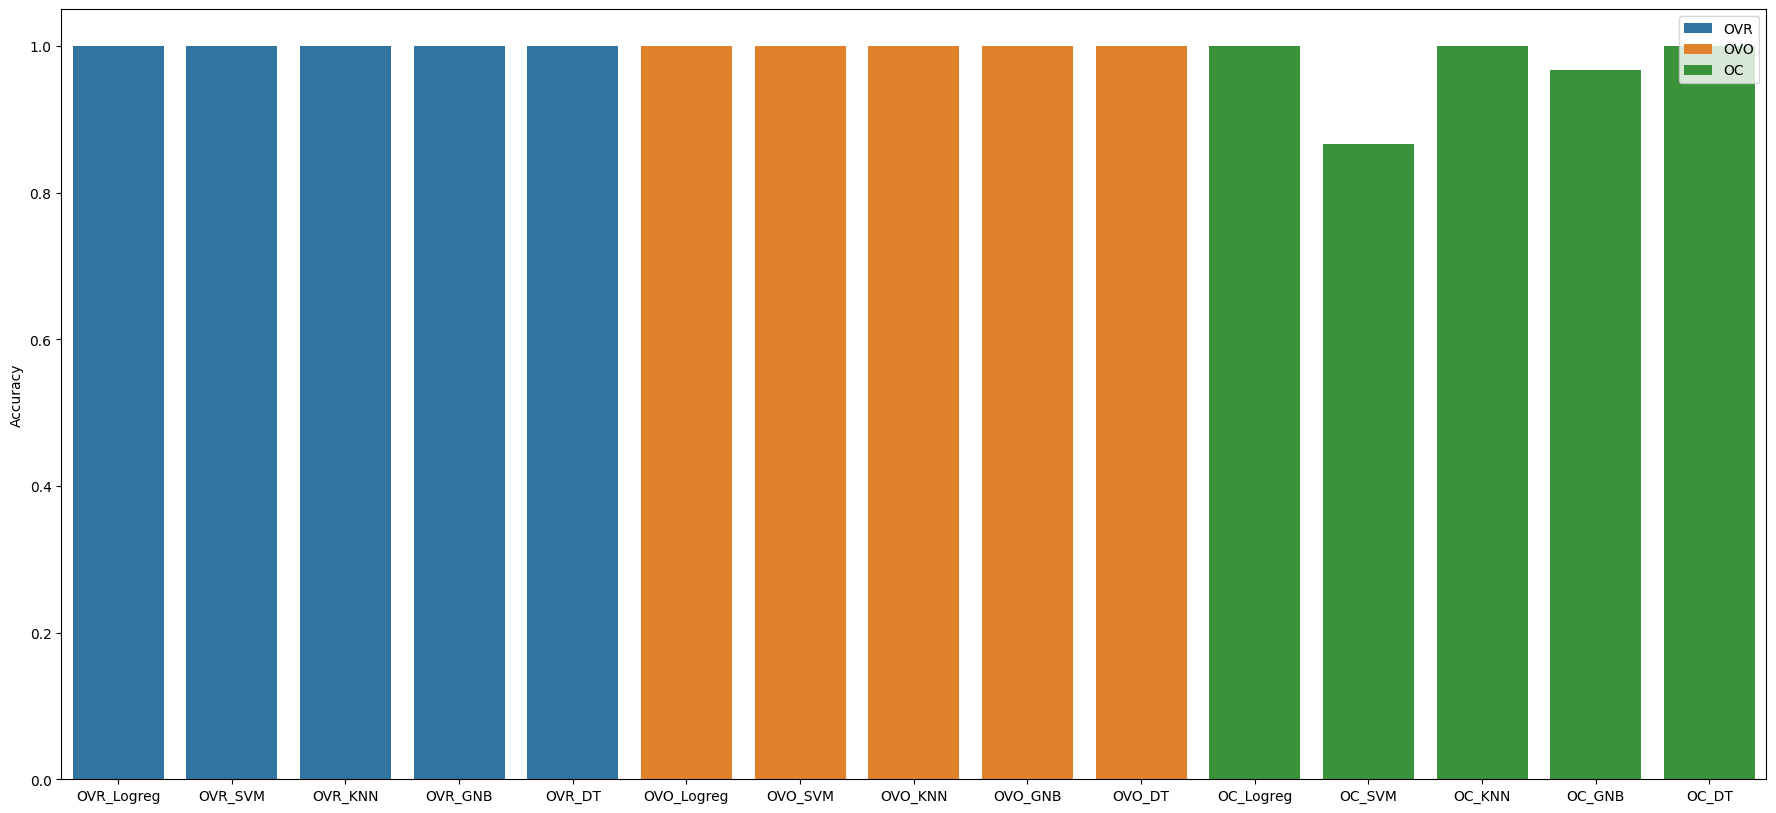

In [84]:

plt.figure(figsize=(22, 10))
plt.ylabel("Accuracy")
colors = ['OVR']*5 + ['OVO']*5 + ['OC']*5
sns.barplot(y=list(accuracies.values()), x=list(accuracies.keys()), hue=colors)
plt.show()

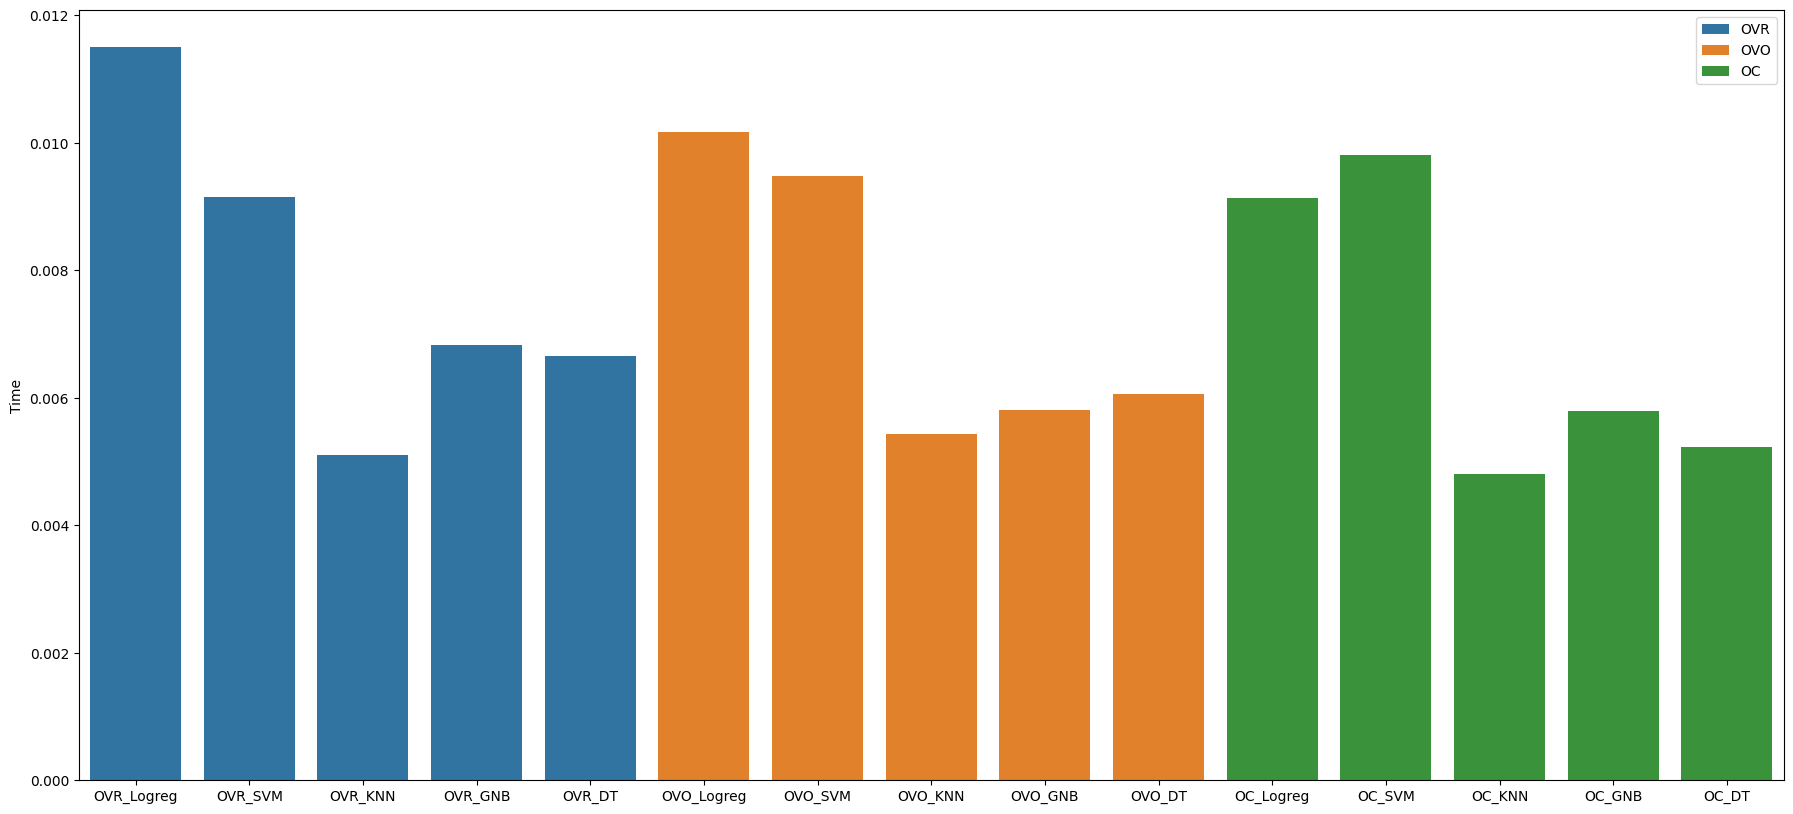

In [85]:

plt.figure(figsize=(22, 10))
plt.ylabel("Time")
sns.barplot(y=list(times.values()), x=list(times.keys()), hue=colors)
plt.show()

# Вывод

наибольшую точность для всех моделей на предложенном датасете показала стратегия OneVsRest и OneVsOne. Менее точный (например, с моделью SVM и GNB), но тоже хорошой результат показала OutputCode.

Наиболее медленной при обучениии в сравнении с остальными оказалась стратегия  OneVsOne, а самой быстрой на большинстве моделей -- OutputCode.

Наиболее быстрый результат показала модель KNN со стратегией OneVsOne.

## 2. Повторить все пункты для задачи Multioutput Regression (регрессия с несколькими целевыми признаками, вещественными). Модель попробовать как минимум одну: Ridge. В качестве стратегий попробовать MultiOutputRegressor и RegressorChain. В качестве метрики использовать R2.

Использую датасет из задачи 1

In [86]:
data2 = pd.read_csv(r"/content/cleaned_data.csv")
data2

,last_price,total_area,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,price_per_area
0,13000000.0,108.00,3,2.700000,16.0,51.000000,8,1,0,0,25.000000,1.150082,34,18863.000000,16028.000000,1.000000,482.000000,2.000000,755.0000,120370.370370
1,3350000.0,40.40,1,2.771499,11.0,18.600000,1,1,0,0,11.000000,2.000000,327,12817.000000,18603.000000,0.000000,490.804555,0.000000,517.9809,82920.792079
2,5196000.0,56.00,2,2.771499,5.0,34.300000,4,1,0,0,8.300000,0.000000,34,21741.000000,13933.000000,1.000000,90.000000,2.000000,574.0000,92785.714286
3,64900000.0,159.00,3,2.771499,14.0,34.457852,9,1,0,0,10.569807,0.000000,34,28098.000000,6800.000000,2.000000,84.000000,3.000000,234.0000,408176.100629
4,10000000.0,100.00,2,3.030000,14.0,32.000000,13,1,0,0,41.000000,1.150082,34,31856.000000,8098.000000,2.000000,112.000000,1.000000,48.0000,100000.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23694,9700000.0,133.81,3,3.700000,5.0,73.300000,3,1,0,0,13.830000,1.150082,34,24665.000000,4232.000000,1.000000,796.000000,3.000000,381.0000,72490.845228
23695,3100000.0,59.00,3,2.771499,5.0,38.000000,4,1,0,0,8.500000,1.150082,42,28793.672193,14191.277833,0.611408,490.804555,0.770255,517.9809,52542.372881
23696,2500000.0,56.70,2,2.771499,3.0,29.700000,1,1,0,0,10.569807,1.150082,361,28793.672193,14191.277833,0.611408,490.804555,0.770255,517.9809,44091.710758
23697,11475000.0,76.75,2,3.000000,17.0,34.457852,12,1,0,0,23.300000,2.000000,34,39140.000000,10364.000000,2.000000,173.000000,3.000000,196.0000,149511.400651


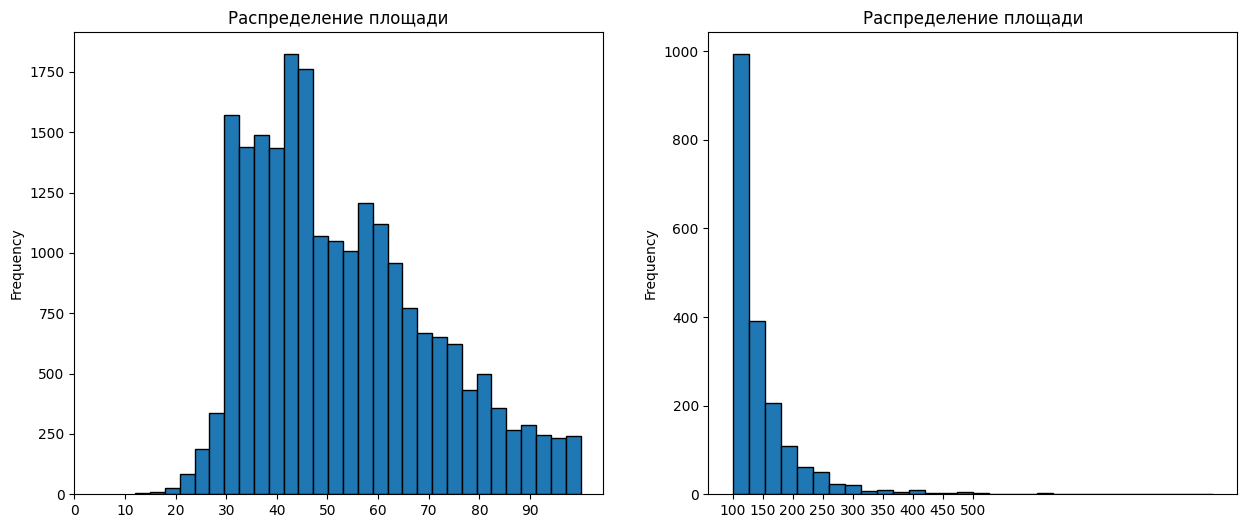

In [87]:
_, ax = plt.subplots(1, 2, figsize=(15, 6))
data2[data2['total_area'] <= 100]['total_area'].plot.hist(ax=ax[0], edgecolor='black', bins=30)
ax[0].set_title('Распределение площади')
x1 = list(range(0, 100, 10))
ax[0].set_xticks(x1)
data2[data2['total_area'] >= 100]['total_area'].plot.hist(ax=ax[1], edgecolor='black', bins=30)
ax[1].set_title('Распределение площади')
x1 = list(range(100, 550, 50))
ax[1].set_xticks(x1)

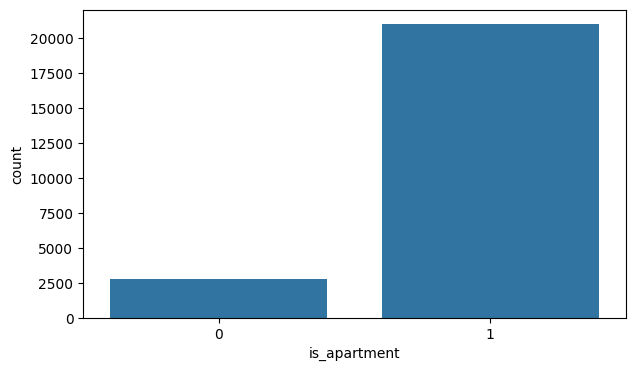

In [88]:
plt.figure(figsize=(7, 4))
sns.countplot(x=data2["is_apartment"])
plt.show()

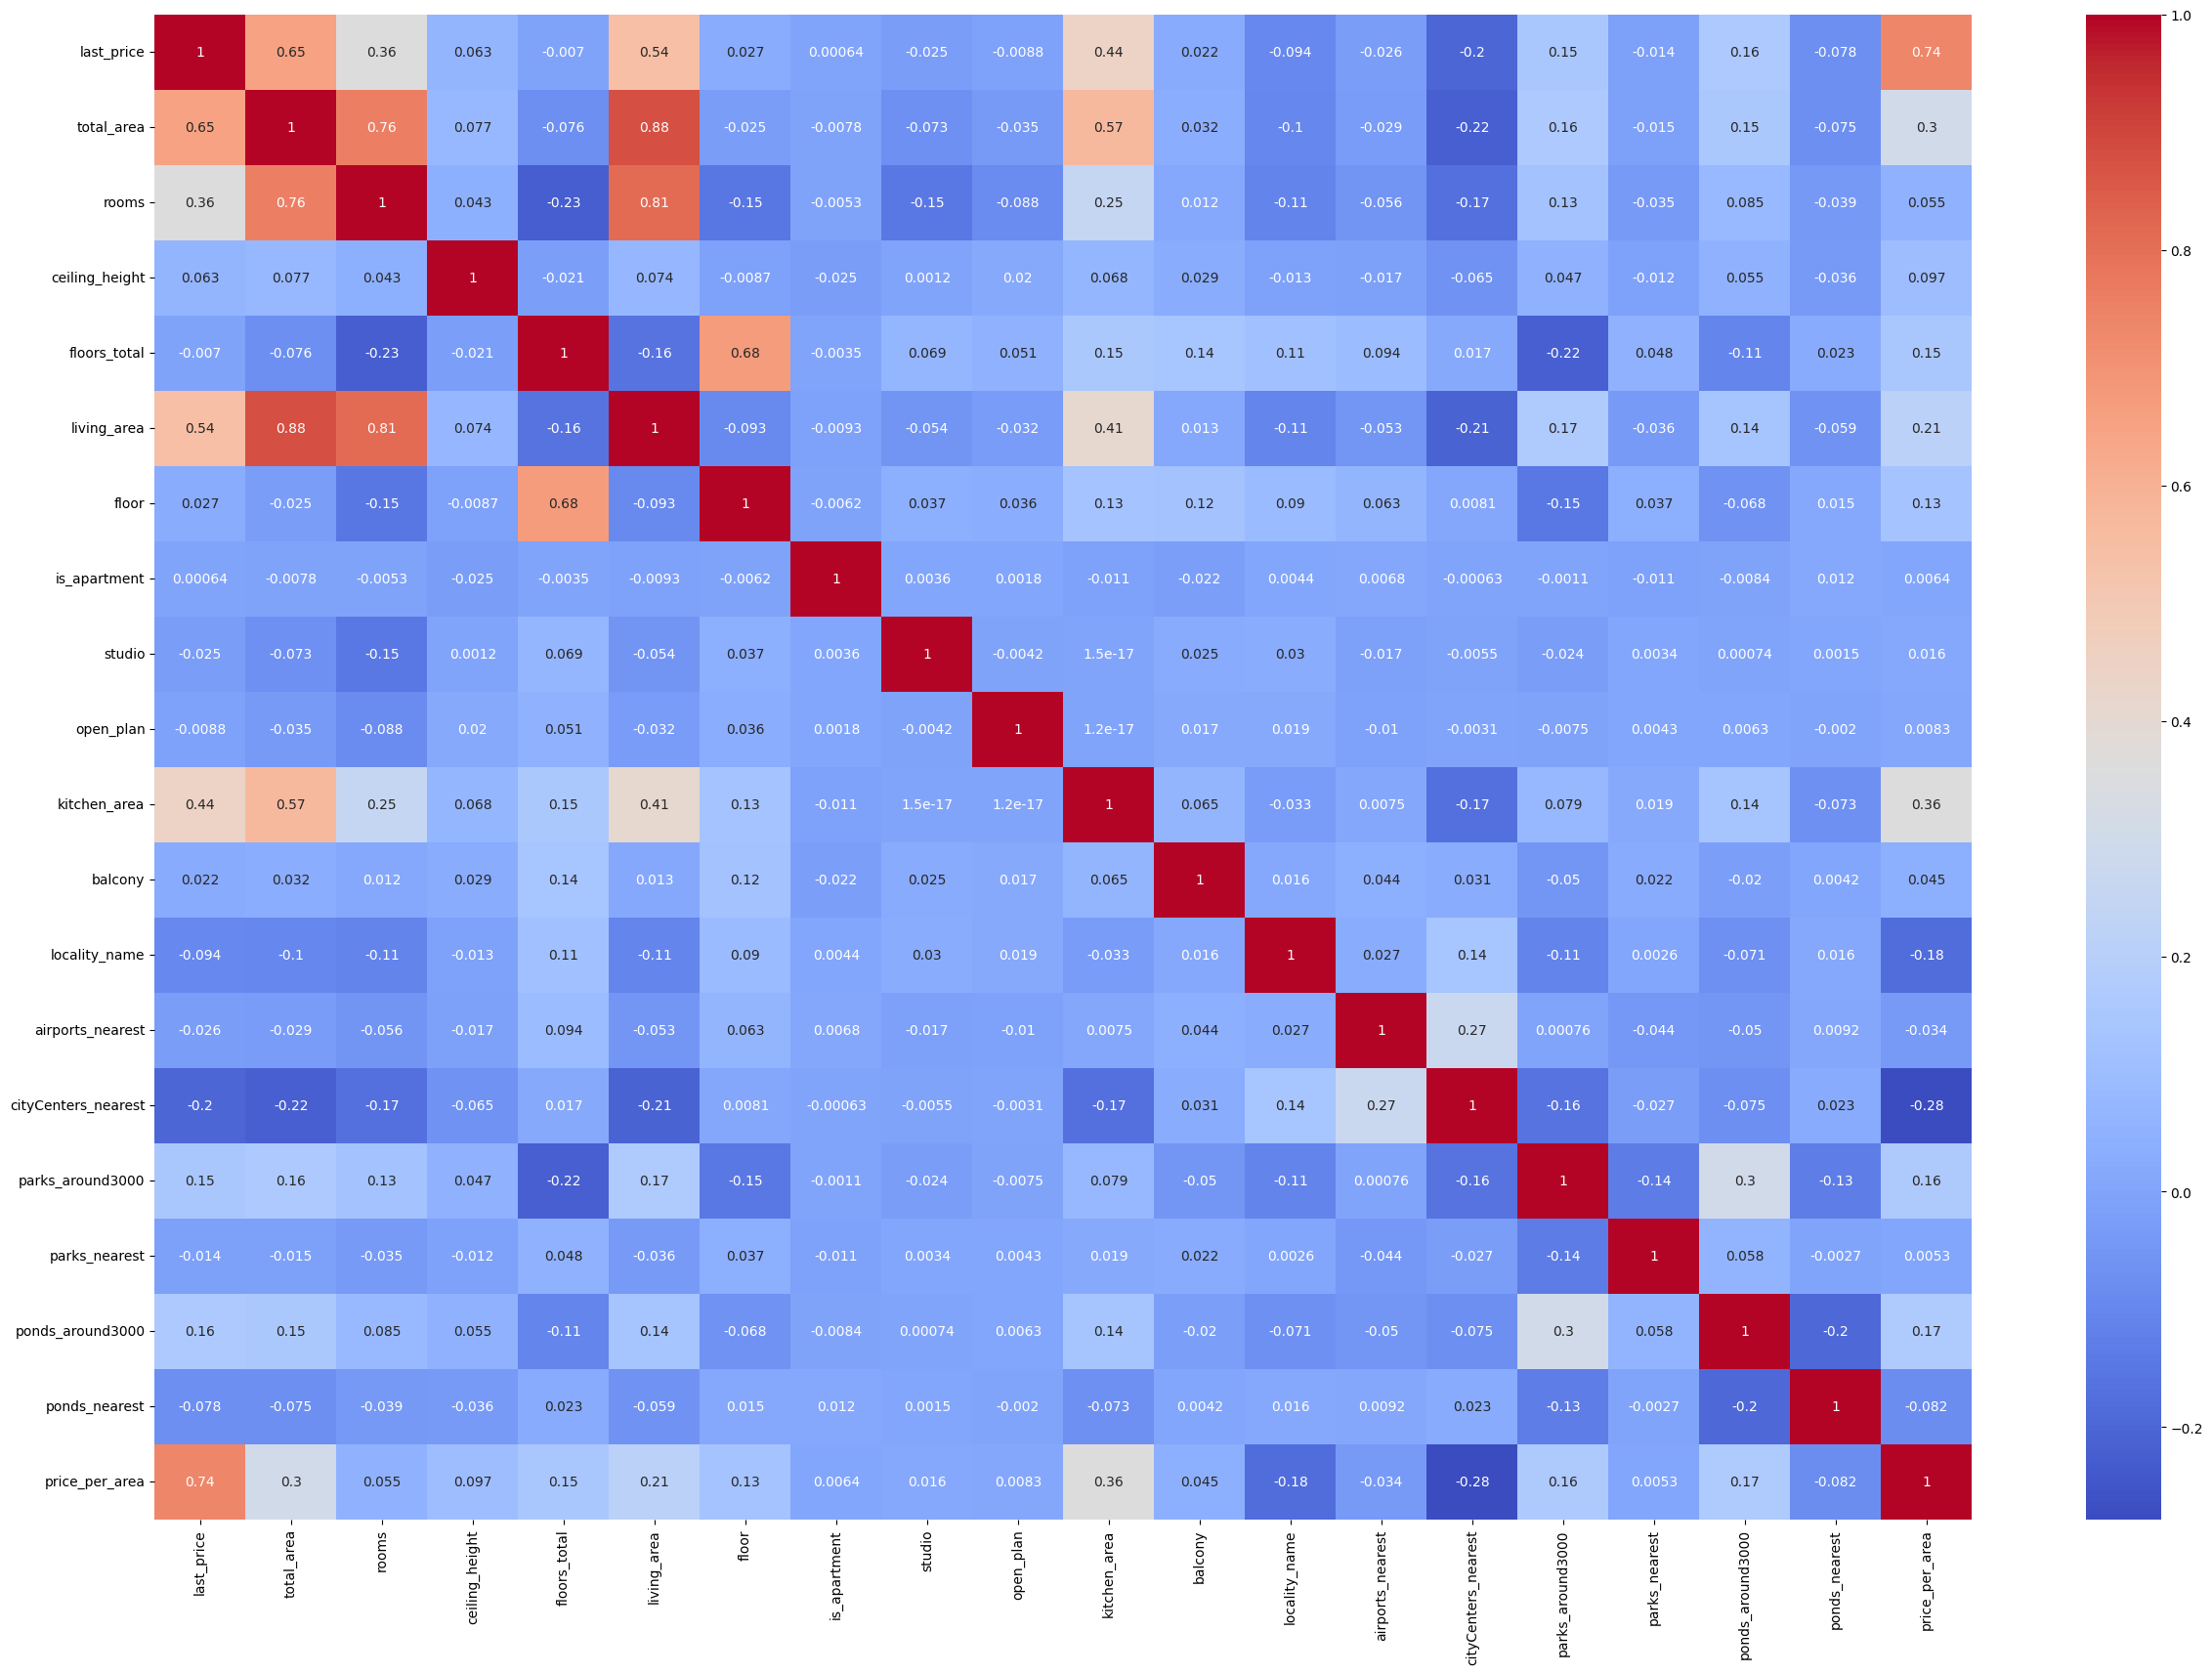

In [89]:
corr_matrix = data2.corr()
plt.figure(figsize=(30, 20))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

In [90]:
y = data2[['last_price','parks_around3000','airports_nearest']]
X = data2.drop(['last_price','parks_around3000','airports_nearest'], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=37)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

accuracies = {}
times = {}

In [91]:

param_grid = {"alpha": np.logspace(-5, 3, 20)}

searcher = GridSearchCV(Ridge(), param_grid, scoring="r2", cv=5)
searcher.fit(X_train_scaled, y_train)

best_ridge_params = searcher.best_params_
print(best_ridge_params)

{'alpha': 379.2690190732246}


In [92]:
mor_ridge = MultiOutputRegressor(Ridge(**best_ridge_params))
mor_ridge.fit(X_train_scaled, y_train)
y_pred = mor_ridge.predict(X_test_scaled)
fit_time = measure_fit_time(mor_ridge, X_train_scaled, y_train)
r2 = r2_score(y_test, y_pred)
accuracies["MOR_Ridge"] = r2
times["MOR_Ridge"] = fit_time
print(f"MOR_Ridge R^2 {r2}")
print(f"MOR_Ridge time {fit_time}")

MOR_Ridge R^2 0.37002865642751764
MOR_Ridge time 0.021535205841064452


In [93]:
rc_ridge = RegressorChain(Ridge(**best_ridge_params))
rc_ridge.fit(X_train_scaled, y_train)
y_pred = rc_ridge.predict(X_test_scaled)
fit_time = measure_fit_time(rc_ridge, X_train_scaled, y_train)
r2 = r2_score(y_test, y_pred)
accuracies["RC_Ridge"] = r2
times["RC_Ridge"] = fit_time
print(f"RC_Ridge R^2 {r2}")
print(f"RC_Ridge time {fit_time}")

RC_Ridge R^2 0.37002865642751753
RC_Ridge time 0.028577184677124022


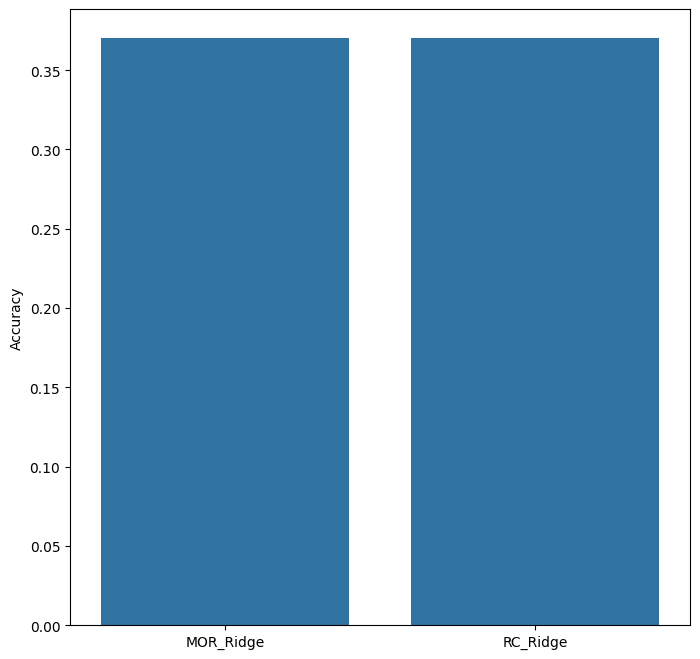

In [94]:
plt.figure(figsize=(8, 8))
plt.ylabel("Accuracy")

sns.barplot(y=list(accuracies.values()), x=list(accuracies.keys()))
plt.show()

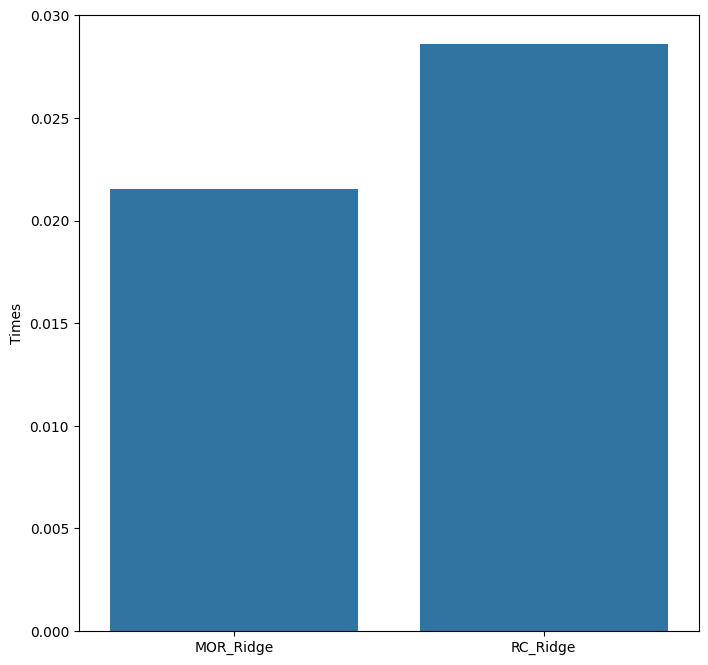

In [95]:
plt.figure(figsize=(8, 8))
plt.ylabel("Times")

sns.barplot(y=list(times.values()), x=list(times.keys()))
plt.show()


## Вывод

На предложенном датасете обе стратегии показывают практически одинаковые результаты по времени обучения, а по точности RC_Ridge лучше.




## 3. MultiOutputClassifier / classfierChain

Biomedical PubMed Multilabel Classification dataset from Kaggle.

In [99]:
df = pd.read_csv('/content/PubMed Multi Label Text Classification Dataset.csv')
df = df.drop(['Title', 'meshMajor', 'pmid', 'meshid', 'meshroot'], axis =1)
df

,abstractText,A,B,C,D,E,F,G,H,I,J,K,L,M,N,V,Z
0,Fifty-four paraffin embedded tissue sections f...,0,1,1,1,1,0,0,1,0,0,0,0,0,0,0,0
1,The present cross-sectional study was conducte...,0,1,1,1,1,1,1,0,1,1,0,0,1,1,0,1
2,The occurrence of individual amino acids and d...,1,1,0,1,1,0,1,0,0,0,0,1,0,0,0,0
3,"In 1980, Lim and Sun introduced a microcapsule...",1,1,1,1,1,0,1,0,0,1,0,0,0,0,0,0
4,Substantially improved hydrogel particles base...,1,1,0,1,1,0,1,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,Lung cancer is the most preventable neoplastic...,0,1,1,0,1,1,0,0,1,0,1,0,1,1,0,1
9996,BACKGROUND: Familial hypercholesterolaemia (FH...,1,1,1,1,1,0,1,0,0,0,0,0,1,1,0,0
9997,The purpose of this work was to develop a nove...,1,1,0,1,1,0,1,0,0,1,0,0,0,0,0,0
9998,The perceptual and affective responses of 44 w...,0,1,0,0,1,1,0,0,0,1,1,1,1,0,0,0


In [100]:
df.isnull().sum()

,0
abstractText,0
A,0
B,0
C,0
D,0
E,0
F,0
G,0
H,0
I,0


In [101]:
X = df["abstractText"]
y = np.asarray(df[df.columns[1:]])

vectorizer = TfidfVectorizer(max_features=2500, max_df=0.9)
vectorizer.fit(X)

TfidfVectorizer(max_df=0.9, max_features=2500)

In [102]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)

X_train_vec = vectorizer.transform(X_train)
X_test_vec = vectorizer.transform(X_test)

## MultiClassifierOutput

In [103]:
param_dist_nb = {
    'estimator__alpha': np.logspace(-3, 3, 7),
    'estimator__fit_prior': [True, False],
}


MOC_nb = MultiOutputClassifier(MultinomialNB())


kfold = KFold(n_splits=5, shuffle=True, random_state=42)

random_search_nb = RandomizedSearchCV(
    MOC_nb,
    param_distributions=param_dist_nb,
    n_iter=10,
    cv=kfold,
    n_jobs=-1,
    verbose=1,
    scoring='accuracy',
    error_score='raise'
)


random_search_nb.fit(X_train_vec, y_train)

best_model_nb = random_search_nb.best_estimator_

predictions_nb = best_model_nb.predict(X_test_vec)

print('Best Parameters for Naive Bayes: ', random_search_nb.best_params_)


print('Accuracy Score: ', accuracy_score(y_test, predictions_nb))
print('Hamming Loss: ', round(hamming_loss(y_test, predictions_nb), 2))


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters for Naive Bayes:  {'estimator__fit_prior': True, 'estimator__alpha': 0.001}
Accuracy Score:  0.108
Hamming Loss:  0.14


In [104]:
fit_time = measure_fit_time(MOC_nb, X_train_vec, y_train)
times["MOC_nb"] = fit_time
print(f"MOC_nb time {fit_time}")

MOC_nb time 0.09308881759643554


## ClassifierChain

In [106]:
param_dist_nb = {
    'base_estimator__alpha': np.logspace(-3, 3, 7),
    'base_estimator__fit_prior': [True, False],
}


CC_nb = MultinomialNB()


chain = ClassifierChain(CC_nb)


kfold = KFold(n_splits=5, shuffle=True, random_state=42)


random_search_chain = RandomizedSearchCV(
    chain,
    param_distributions=param_dist_nb,
    n_iter=10,
    cv=kfold,
    n_jobs=-1,
    verbose=1,
    scoring='accuracy',
)


random_search_chain.fit(X_train_vec, y_train)


best_model_chain = random_search_chain.best_estimator_


predictions_chain = best_model_chain.predict(X_test_vec)


print('Best Parameters for Naive Bayes with ClassifierChain: ', random_search_chain.best_params_)


print('Accuracy Score: ', accuracy_score(y_test, predictions_chain))
print('Hamming Loss: ', round(hamming_loss(y_test, predictions_chain), 2))



Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters for Naive Bayes with ClassifierChain:  {'base_estimator__fit_prior': True, 'base_estimator__alpha': 0.1}
Accuracy Score:  0.097
Hamming Loss:  0.15


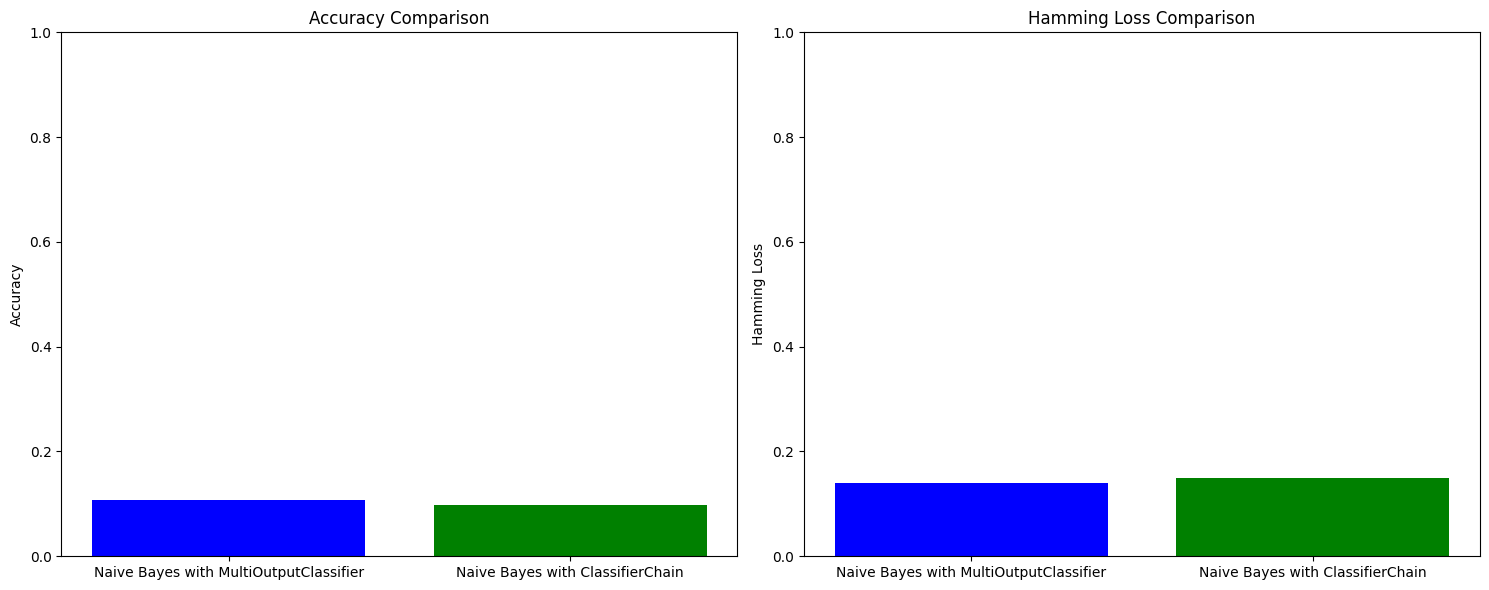

Accuracy for Naive Bayes with MultiOutputClassifier: 0.108
Hamming Loss for Naive Bayes with MultiOutputClassifier: 0.14
Accuracy for Naive Bayes with ClassifierChain: 0.097
Hamming Loss for Naive Bayes with ClassifierChain: 0.15


In [107]:

import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, hamming_loss
import numpy as np

accuracy_nb = accuracy_score(y_test, predictions_nb)
hamming_nb = round(hamming_loss(y_test, predictions_nb), 2)

accuracy_chain = accuracy_score(y_test, predictions_chain)
hamming_chain = round(hamming_loss(y_test, predictions_chain), 2)

models = ['Naive Bayes with MultiOutputClassifier', 'Naive Bayes with ClassifierChain']
accuracies = [accuracy_nb, accuracy_chain]
hamming_losses = [hamming_nb, hamming_chain]

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.bar(models, accuracies, color=['blue', 'green'])
plt.title('Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim([0, 1])


plt.subplot(1, 2, 2)
plt.bar(models, hamming_losses, color=['blue', 'green'])
plt.title('Hamming Loss Comparison')
plt.ylabel('Hamming Loss')
plt.ylim([0, 1])


plt.tight_layout()
plt.show()

# Print out the accuracies and Hamming Loss
print(f"Accuracy for Naive Bayes with MultiOutputClassifier: {accuracy_nb}")
print(f"Hamming Loss for Naive Bayes with MultiOutputClassifier: {hamming_nb}")

print(f"Accuracy for Naive Bayes with ClassifierChain: {accuracy_chain}")
print(f"Hamming Loss for Naive Bayes with ClassifierChain: {hamming_chain}")


## Вывод

На предложенном датасете обе стратегии показывают практически одинаковые результаты  по точности.